<a href="https://www.kaggle.com/code/lalit7881/cryptocurrency-social-media-signals-global-eda?scriptVersionId=314477199" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zkskhurram/cryptocurrency-social-media-signals-global/source_provenance.csv
/kaggle/input/datasets/zkskhurram/cryptocurrency-social-media-signals-global/crypto_social_signals_daily.csv
/kaggle/input/datasets/zkskhurram/cryptocurrency-social-media-signals-global/crypto_asset_snapshot.csv


## Loading dataset

In [2]:
daily = pd.read_csv("/kaggle/input/datasets/zkskhurram/cryptocurrency-social-media-signals-global/crypto_social_signals_daily.csv")
snapshot = pd.read_csv("/kaggle/input/datasets/zkskhurram/cryptocurrency-social-media-signals-global/crypto_asset_snapshot.csv")
source = pd.read_csv("/kaggle/input/datasets/zkskhurram/cryptocurrency-social-media-signals-global/source_provenance.csv")

In [3]:
print(daily.head())
print(daily.info())
print(daily.describe())

# Missing values
print(daily.isnull().sum())

         date      coin_id   price_usd  market_cap_usd    volume_usd  \
0  2025-04-24  binancecoin  606.174282    8.843929e+10  1.089224e+09   
1  2025-04-25  binancecoin  602.197068    8.785977e+10  7.758590e+08   
2  2025-04-26  binancecoin  600.191388    8.755807e+10  9.419844e+08   
3  2025-04-27  binancecoin  607.808538    8.866769e+10  6.329642e+08   
4  2025-04-28  binancecoin  603.537146    8.805031e+10  5.483790e+08   

   fear_greed_value fear_greed_classification  wiki_views  twitter_followers  \
0                63                     Greed         5.0                NaN   
1                60                     Greed         4.0                NaN   
2                65                     Greed         3.0                NaN   
3                61                     Greed         4.0                NaN   
4                54                   Neutral         2.0                NaN   

   reddit_subscribers  ...  github_stars  github_forks  symbol  name  \
0             

In [4]:
print("DAILY COLUMNS:\n", daily.columns)
print("\nSNAPSHOT COLUMNS:\n", snapshot.columns)
print("\nSOURCE COLUMNS:\n", source.columns)

DAILY COLUMNS:
 Index(['date', 'coin_id', 'price_usd', 'market_cap_usd', 'volume_usd',
       'fear_greed_value', 'fear_greed_classification', 'wiki_views',
       'twitter_followers', 'reddit_subscribers', 'reddit_active_users_48h',
       'telegram_channel_user_count', 'github_stars', 'github_forks', 'symbol',
       'name', 'market_cap_rank', 'source_price', 'source_social',
       'source_wiki', 'source_sentiment', 'retrieved_at_utc'],
      dtype='object')

SNAPSHOT COLUMNS:
 Index(['coin_id', 'symbol', 'name', 'price_usd', 'market_cap_usd',
       'market_cap_rank', 'volume_usd_24h', 'price_change_24h_pct',
       'price_change_7d_pct', 'circulating_supply', 'total_supply',
       'max_supply', 'all_time_high_usd', 'all_time_low_usd', 'last_updated',
       'twitter_followers', 'reddit_subscribers', 'reddit_active_users_48h',
       'telegram_channel_user_count', 'github_stars', 'github_forks',
       'source_price', 'source_social', 'retrieved_at_utc'],
      dtype='object')

SO

In [5]:
df = pd.merge(
    daily,
    snapshot,
    on='coin_id',
    how='left',
    suffixes=('_daily', '_snap')
)

In [6]:
df = df[[col for col in df.columns if not col.endswith('_snap')]]

In [7]:
print(df.columns)

Index(['date', 'coin_id', 'price_usd_daily', 'market_cap_usd_daily',
       'volume_usd', 'fear_greed_value', 'fear_greed_classification',
       'wiki_views', 'twitter_followers_daily', 'reddit_subscribers_daily',
       'reddit_active_users_48h_daily', 'telegram_channel_user_count_daily',
       'github_stars_daily', 'github_forks_daily', 'symbol_daily',
       'name_daily', 'market_cap_rank_daily', 'source_price_daily',
       'source_social_daily', 'source_wiki', 'source_sentiment',
       'retrieved_at_utc_daily', 'volume_usd_24h', 'price_change_24h_pct',
       'price_change_7d_pct', 'circulating_supply', 'total_supply',
       'max_supply', 'all_time_high_usd', 'all_time_low_usd', 'last_updated'],
      dtype='object')


## EDA

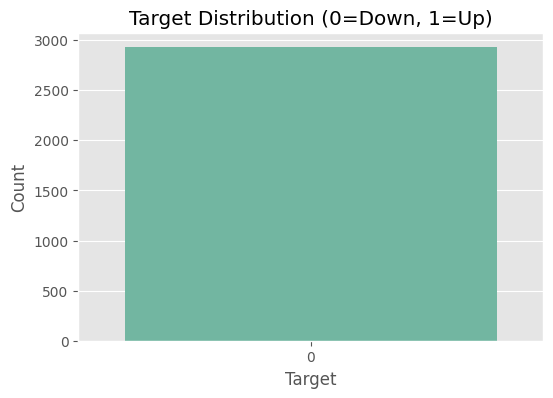

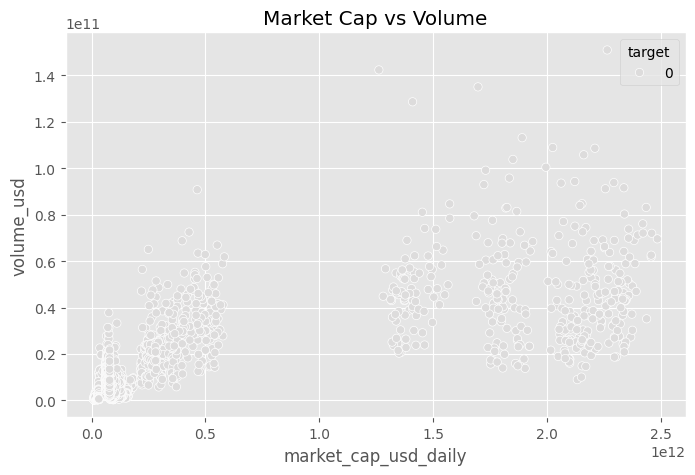

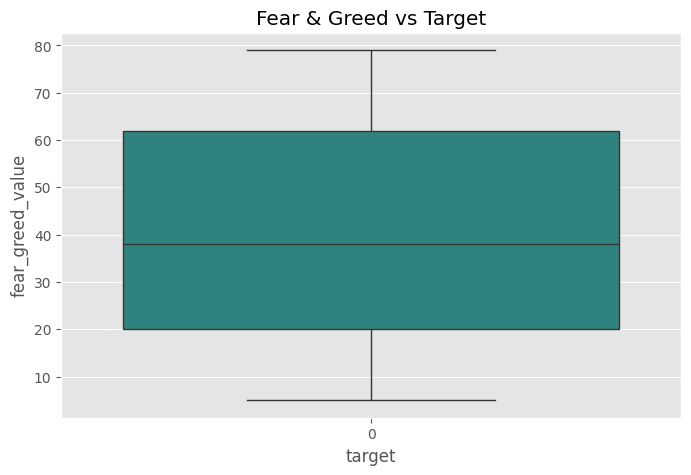

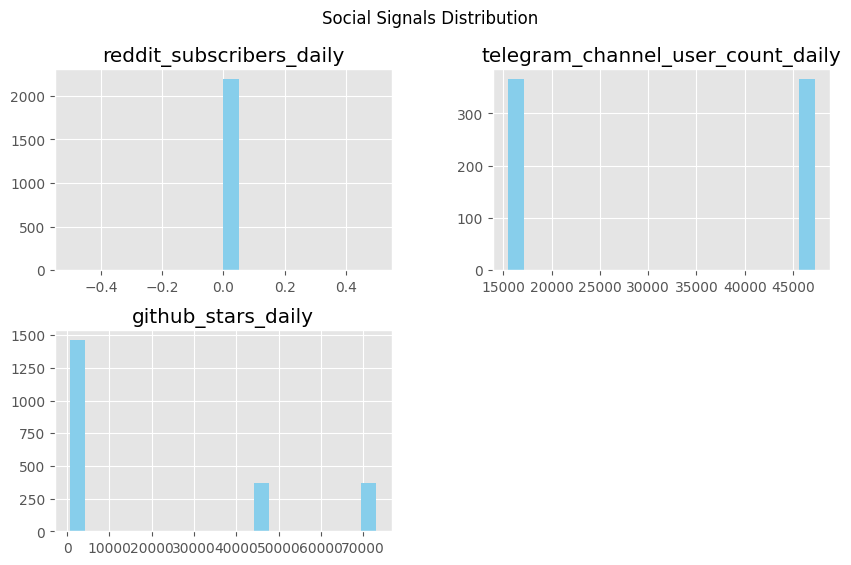

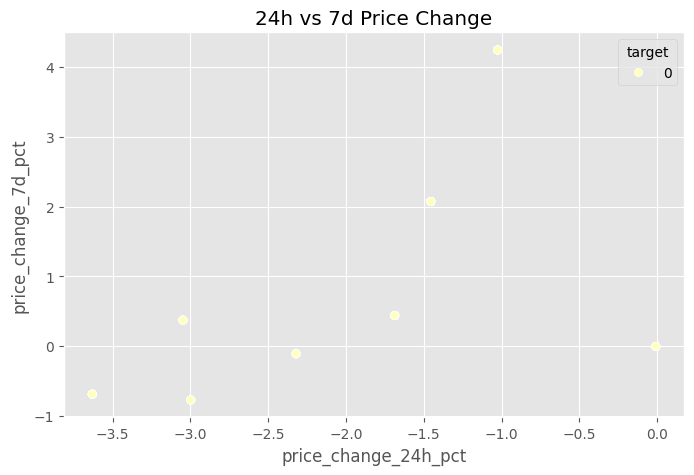

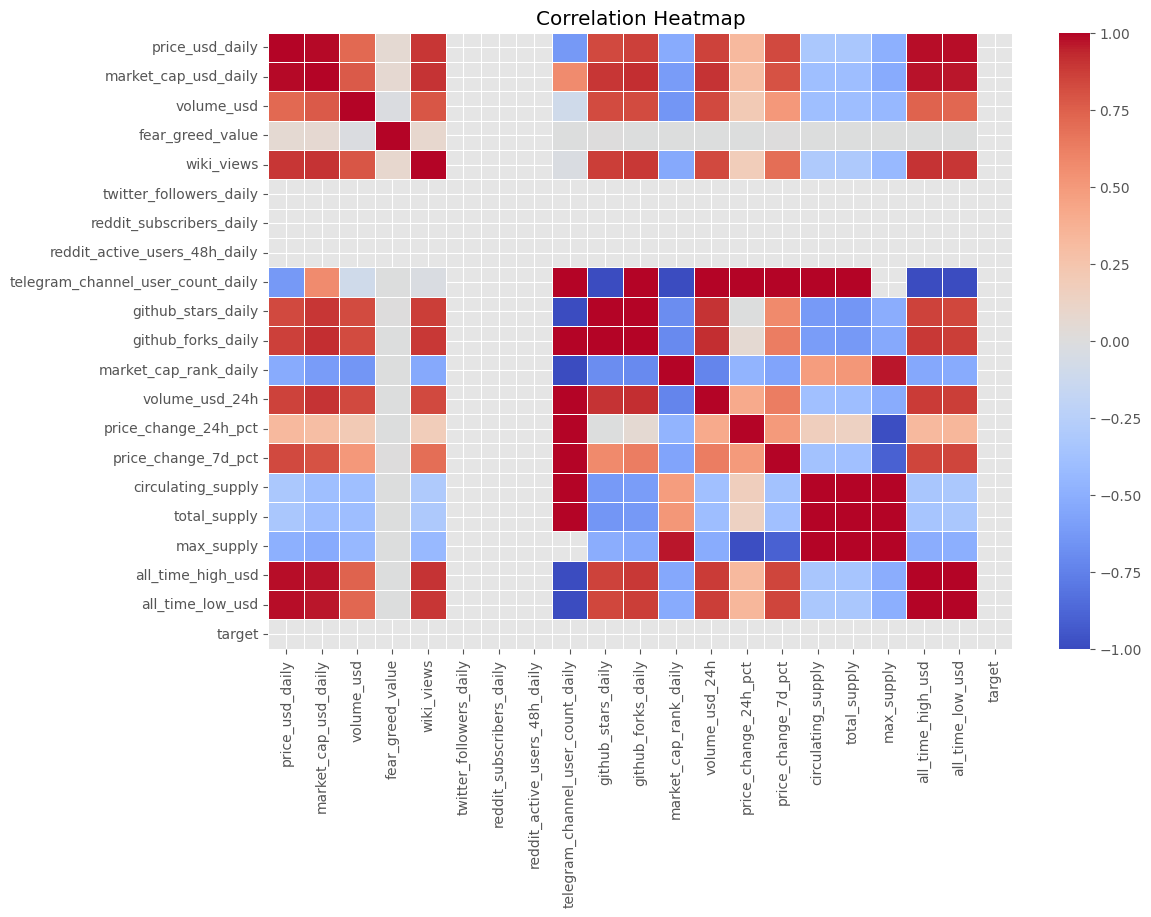

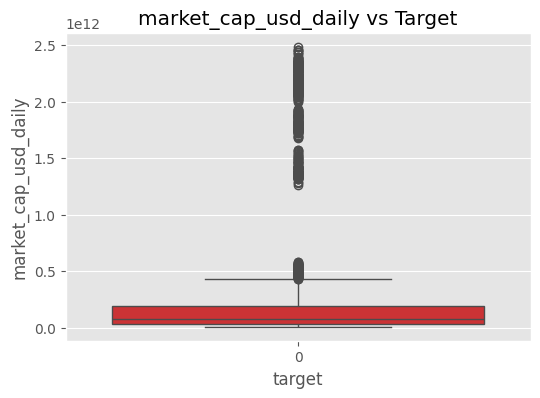

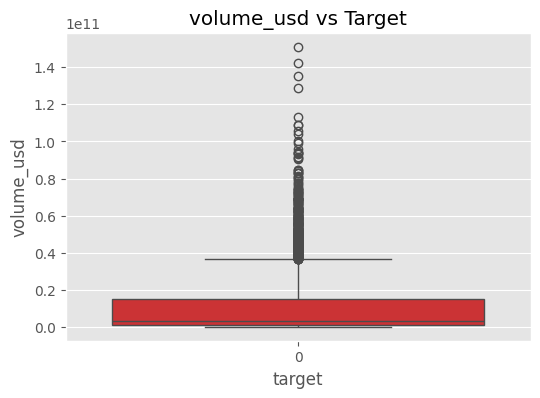

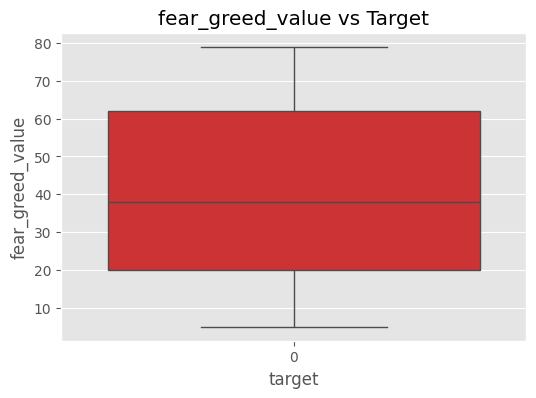

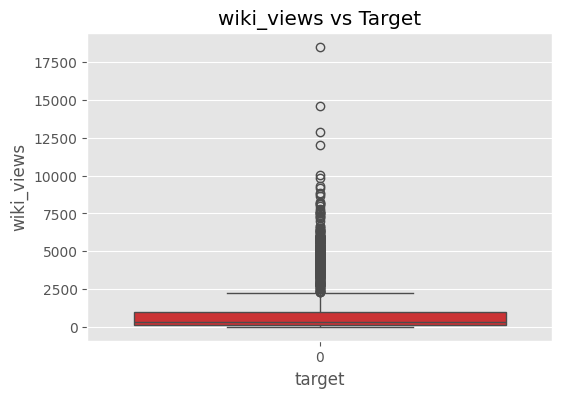

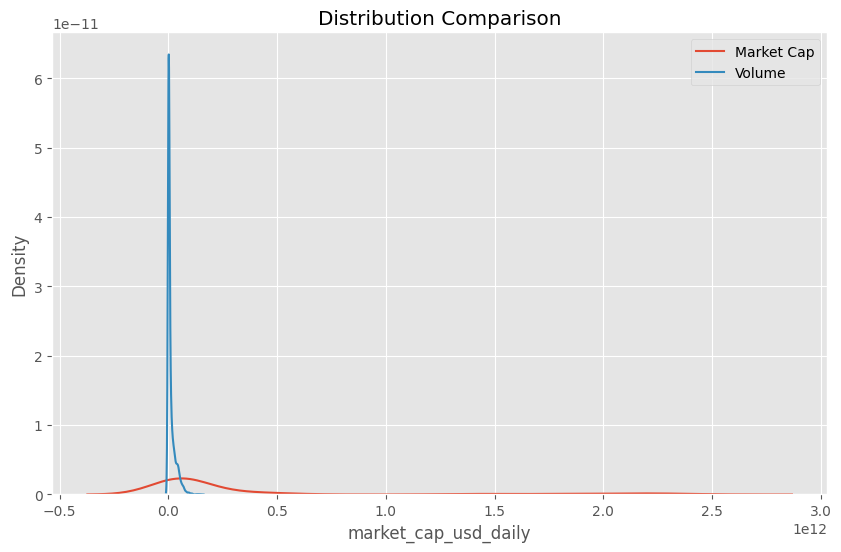

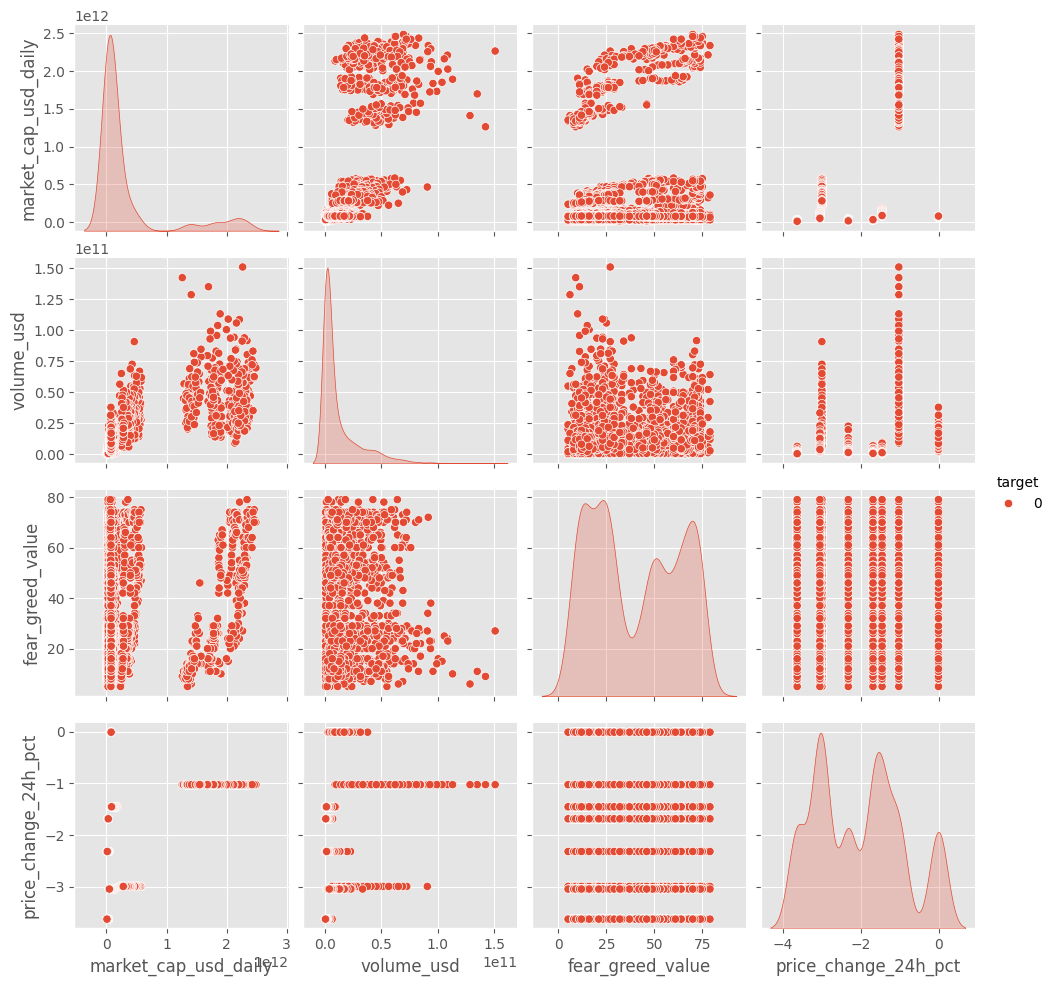

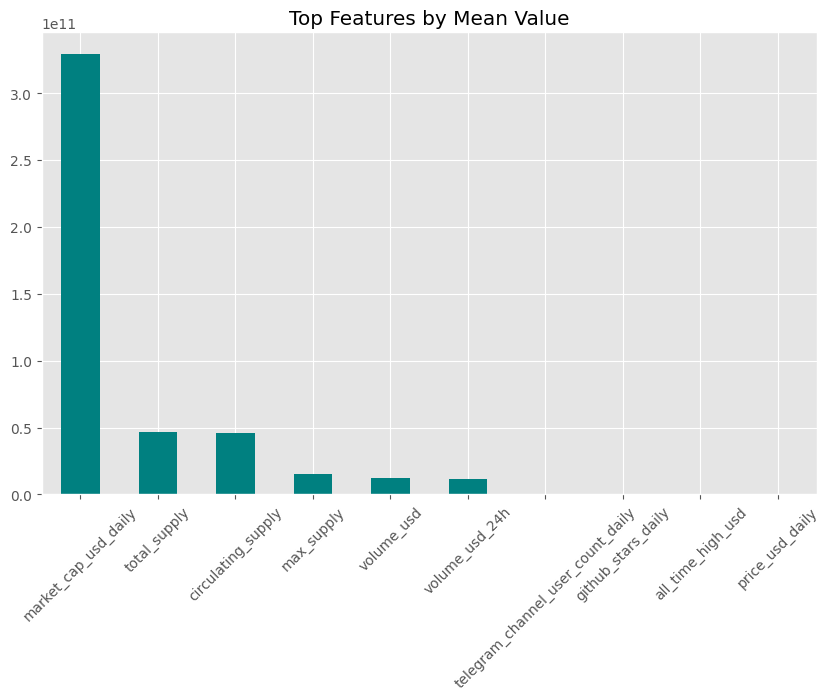

In [8]:

plt.style.use('ggplot')


# ================================
# 2. SAFETY CHECK (VERY IMPORTANT)
# ================================
# Ensure df is a DataFrame
if not isinstance(df, pd.DataFrame):
    raise ValueError("❌ df is not a DataFrame. Reload dataset.")

# Create target if missing
if 'target' not in df.columns:
    if 'price_change_24h_pct' in df.columns:
        df['target'] = (df['price_change_24h_pct'] > 0).astype(int)

# Helper function
def has_cols(cols):
    return all(col in df.columns for col in cols)


# ================================
# 3. TARGET DISTRIBUTION
# ================================
if 'target' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='target', hue='target', palette='Set2', legend=False)
    plt.title("Target Distribution (0=Down, 1=Up)")
    plt.xlabel("Target")
    plt.ylabel("Count")
    plt.show()


# ================================
# 4. MARKET CAP vs VOLUME
# ================================
if has_cols(['market_cap_usd_daily','volume_usd']):
    plt.figure(figsize=(8,5))
    sns.scatterplot(
        data=df,
        x='market_cap_usd_daily',
        y='volume_usd',
        hue='target' if 'target' in df.columns else None,
        palette='coolwarm'
    )
    plt.title("Market Cap vs Volume")
    plt.show()


# ================================
# 5. FEAR & GREED ANALYSIS
# ================================
if has_cols(['fear_greed_value','target']):
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x='target', y='fear_greed_value', palette='viridis')
    plt.title("Fear & Greed vs Target")
    plt.show()


# ================================
# 6. SOCIAL SIGNALS DISTRIBUTION
# ================================
social_cols = [
    'reddit_subscribers_daily',
    'telegram_channel_user_count_daily',
    'github_stars_daily'
]

existing_social = [c for c in social_cols if c in df.columns]

if len(existing_social) > 0:
    df[existing_social].hist(figsize=(10,6), bins=20, color='skyblue')
    plt.suptitle("Social Signals Distribution")
    plt.show()


# ================================
# 7. PRICE CHANGE RELATION
# ================================
if has_cols(['price_change_24h_pct','price_change_7d_pct']):
    plt.figure(figsize=(8,5))
    sns.scatterplot(
        data=df,
        x='price_change_24h_pct',
        y='price_change_7d_pct',
        hue='target' if 'target' in df.columns else None,
        palette='Spectral'
    )
    plt.title("24h vs 7d Price Change")
    plt.show()


# ================================
# 8. CORRELATION HEATMAP
# ================================
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


# ================================
# 9. TOP FEATURES vs TARGET
# ================================
top_features = [
    'market_cap_usd_daily',
    'volume_usd',
    'fear_greed_value',
    'wiki_views'
]

for col in top_features:
    if col in df.columns and 'target' in df.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(data=df, x='target', y=col, palette='Set1')
        plt.title(f"{col} vs Target")
        plt.show()


# ================================
# 10. TIME-BASED ANALYSIS
# ================================
if has_cols(['dayofweek','volume_usd']):
    plt.figure(figsize=(10,5))
    sns.lineplot(data=df, x='dayofweek', y='volume_usd', color='green')
    plt.title("Volume by Day of Week")
    plt.show()


# ================================
# 11. DISTRIBUTION PLOTS
# ================================
if has_cols(['market_cap_usd_daily','volume_usd']):
    plt.figure(figsize=(10,6))
    sns.kdeplot(data=df, x='market_cap_usd_daily', label='Market Cap')
    sns.kdeplot(data=df, x='volume_usd', label='Volume')
    plt.legend()
    plt.title("Distribution Comparison")
    plt.show()


# ================================
# 12. PAIRPLOT
# ================================
pair_cols = [
    'market_cap_usd_daily',
    'volume_usd',
    'fear_greed_value',
    'price_change_24h_pct',
    'target'
]

pair_cols = [c for c in pair_cols if c in df.columns]

if len(pair_cols) >= 3:
    sns.pairplot(df[pair_cols], hue='target' if 'target' in pair_cols else None)
    plt.show()


# ================================
# 13. FEATURE IMPORTANCE STYLE
# ================================
means = numeric_df.mean().sort_values(ascending=False)[:10]

plt.figure(figsize=(10,6))
means.plot(kind='bar', color='teal')
plt.title("Top Features by Mean Value")
plt.xticks(rotation=45)
plt.show()

## Feature engineering

Merged Shape: (2928, 45)
After cleaning: (2928, 31)
Removing constant columns: ['reddit_subscribers_daily', 'reddit_active_users_48h_daily']
Accuracy: 0.7286689419795221

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73       295
           1       0.73      0.73      0.73       291

    accuracy                           0.73       586
   macro avg       0.73      0.73      0.73       586
weighted avg       0.73      0.73      0.73       586



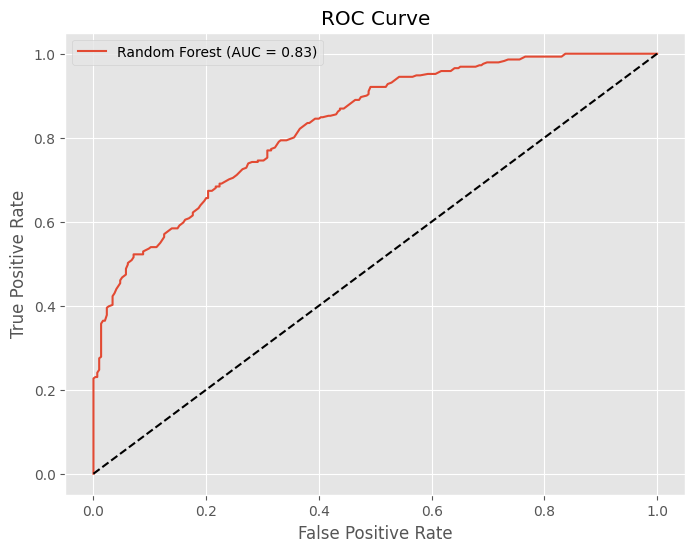

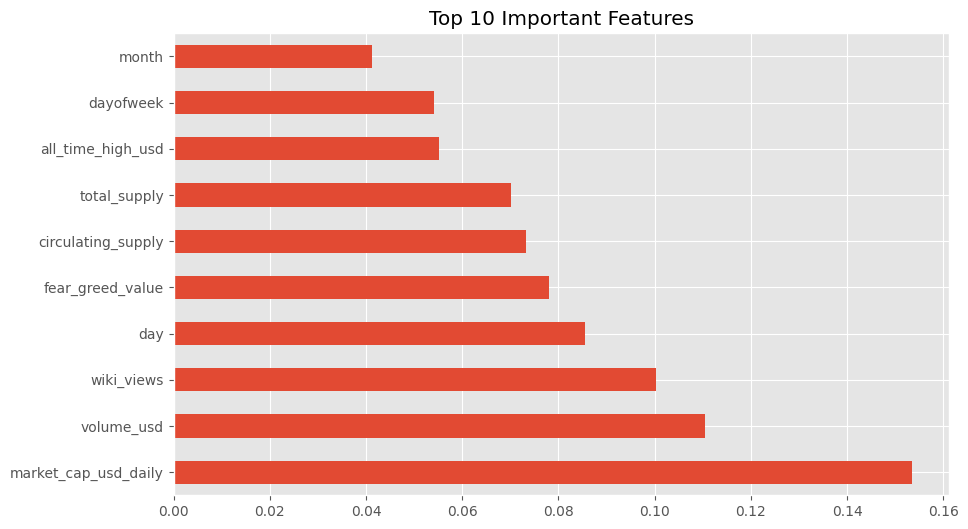

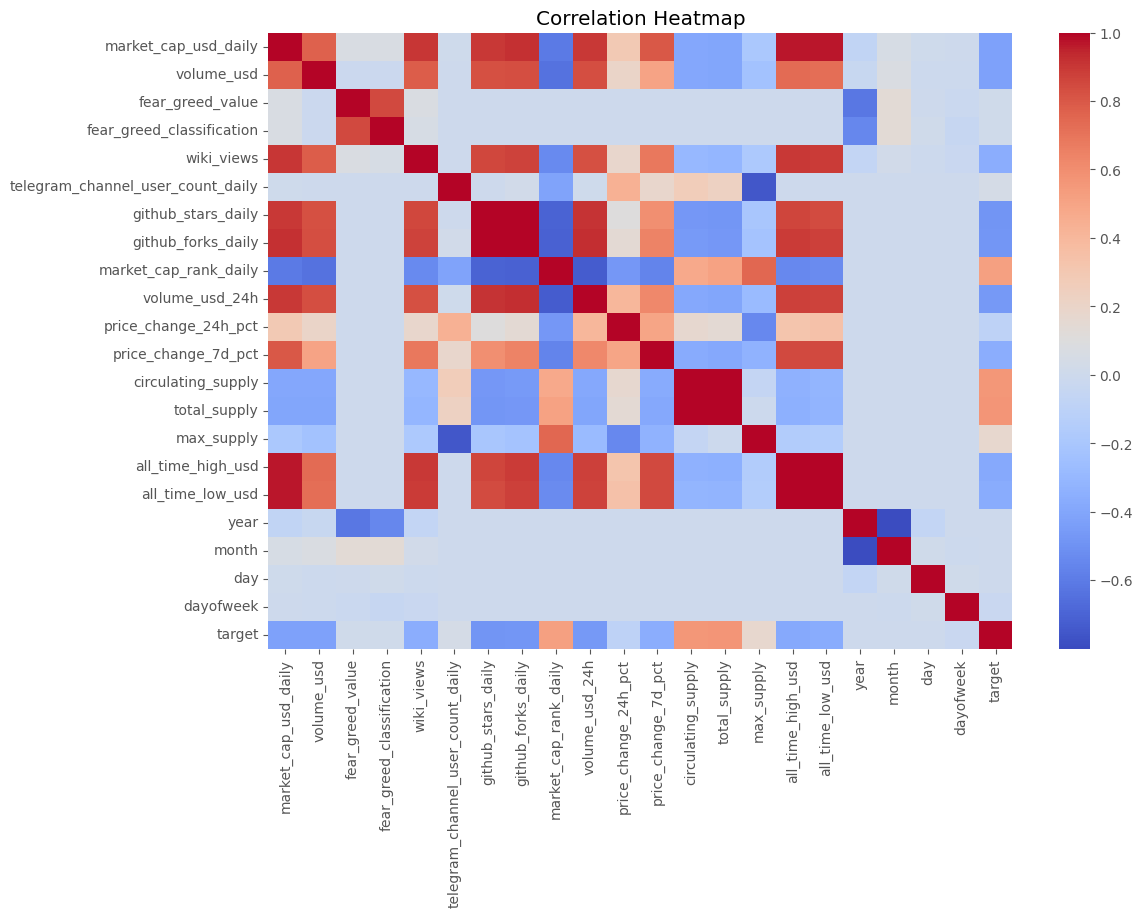

In [9]:
df = pd.merge(
    daily,
    snapshot,
    on='coin_id',
    how='left',
    suffixes=('_daily', '_snap')
)

print("Merged Shape:", df.shape)


# ================================
# 4. REMOVE DUPLICATE COLUMNS
# ================================
duplicate_cols = [col for col in df.columns if col.endswith('_snap')]
df.drop(columns=duplicate_cols, inplace=True)

print("After cleaning:", df.shape)


# ================================
# 5. HANDLE MISSING VALUES
# ================================
# Drop columns with all NaN
df = df.dropna(axis=1, how='all')

# Replace inf values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())


# ================================
# 6. DATE FEATURE ENGINEERING
# ================================
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

df = df.sort_values('date')

# ================================
# 7. TARGET VARIABLE
# ================================
df['target'] = (df['price_usd_daily'].shift(-1) > df['price_usd_daily']).astype(int)

df = df.dropna(subset=['target'])


# ================================
# 8. REMOVE LEAKAGE COLUMNS
# ================================
leak_cols = ['price_usd_daily', 'retrieved_at_utc_daily', 'retrieved_at_utc_snap', 'date']
df.drop(columns=[col for col in leak_cols if col in df.columns], inplace=True)


# ================================
# 9. DROP USELESS COLUMNS
# ================================
drop_cols = [
    'coin_id', 'symbol_daily', 'name_daily',
    'source_price_daily', 'source_social_daily',
    'source_wiki', 'source_sentiment',
    'last_updated'
]

df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)


# ================================
# 10. ENCODE CATEGORICAL
# ================================
le = LabelEncoder()

if 'fear_greed_classification' in df.columns:
    df['fear_greed_classification'] = le.fit_transform(df['fear_greed_classification'])


# ================================
# 11. REMOVE CONSTANT COLUMNS
# ================================
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("Removing constant columns:", constant_cols)

df.drop(columns=constant_cols, inplace=True)


# ================================
# 12. FINAL FEATURES
# ================================
X = df.drop('target', axis=1)
y = df['target']


# ================================
# 13. TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ================================
# 14. SCALING
# ================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ================================
# 15. MODEL TRAINING
# ================================
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]


# ================================
# 16. EVALUATION
# ================================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# ================================
# 17. ROC CURVE
# ================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# ================================
# 18. FEATURE IMPORTANCE
# ================================
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

plt.figure(figsize=(10,6))
feature_importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()


# ================================
# 19. CORRELATION HEATMAP
# ================================
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## thank you...pls upvote!!!!!!!!!!!!